# Samsung Galaxy Lineup — Exploratory Data Analysis

This notebook explores the cleaned `phones.csv` dataset (15 Samsung Galaxy
phones, 2024–2025, Indian pricing) that powers the Galaxy Match
recommendation assistant.

**Goals:**
1. Understand the shape and quality of the dataset
2. Explore price, camera, performance and battery distributions
3. Look at correlations between specs and price
4. Sanity-check the 4 engineered scores (Camera / Performance / Battery / Value) used by the Weighted Sum Model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import sys
sys.path.append("..")  # so we can import project modules from /notebooks
from feature_engineering import load_engineered_phones

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
SAMSUNG_BLUE = "#1428A0"
ACCENT_BLUE = "#2F6FED"

df = load_engineered_phones("../phones.csv")
df.head()

,phone_id,brand,model,release_year,price_inr,ram_gb,storage_gb,battery_mah,charging_w,main_camera_mp,...,processor,display_inch,refresh_rate_hz,display_type,weight_g,category,camera_score,performance_score,battery_score,value_score
0,1,Samsung,Galaxy S24,2024,74999,8,256,4000,25,50,...,Exynos 2400,6.2,120,Dynamic AMOLED 2X,167,flagship,1.26,8.34,0.70,1.06
1,2,Samsung,Galaxy S24+,2024,99999,12,256,4900,45,50,...,Exynos 2400,6.7,120,Dynamic AMOLED 2X,196,flagship,1.26,8.76,9.30,4.33
2,3,Samsung,Galaxy S24 Ultra,2024,129999,12,256,5000,45,200,...,Snapdragon 8 Gen 3,6.8,120,Dynamic AMOLED 2X,232,flagship,8.65,9.25,10.00,6.60
3,4,Samsung,Galaxy S24 FE,2024,59999,8,256,4700,25,50,...,Exynos 2400e,6.7,120,Dynamic AMOLED 2X,213,flagship,1.05,7.60,5.58,3.92
4,5,Samsung,Galaxy S25,2025,79999,12,256,4000,25,50,...,Snapdragon 8 Elite,6.2,120,Dynamic AMOLED 2X,162,flagship,1.26,10.00,0.70,1.71


## 1. Dataset overview

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 15, Columns: 23
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   phone_id           15 non-null     int64  
 1   brand              15 non-null     str    
 2   model              15 non-null     str    
 3   release_year       15 non-null     int64  
 4   price_inr          15 non-null     int64  
 5   ram_gb             15 non-null     int64  
 6   storage_gb         15 non-null     int64  
 7   battery_mah        15 non-null     int64  
 8   charging_w         15 non-null     int64  
 9   main_camera_mp     15 non-null     int64  
 10  ultra_wide_mp      15 non-null     int64  
 11  telephoto_mp       15 non-null     int64  
 12  front_camera_mp    15 non-null     int64  
 13  processor          15 non-null     str    
 14  display_inch       15 non-null     float64
 15  refresh_rate_hz    15 non-null     int64  
 16  display_type     

In [3]:
print("Missing values per column:")
df.isna().sum()

Missing values per column:


phone_id             0
brand                0
model                0
release_year         0
price_inr            0
ram_gb               0
storage_gb           0
battery_mah          0
charging_w           0
main_camera_mp       0
ultra_wide_mp        0
telephoto_mp         0
front_camera_mp      0
processor            0
display_inch         0
refresh_rate_hz      0
display_type         0
weight_g             0
category             0
camera_score         0
performance_score    0
battery_score        0
value_score          0
dtype: int64

In [4]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
phone_id,15.0,8.000000,4.472136,1.0,4.500,8.00,11.500,15.0
release_year,15.0,2024.266667,0.457738,2024.0,2024.000,2024.00,2024.500,2025.0
price_inr,15.0,80599.000000,46221.207254,16999.0,35499.000,79999.00,109999.000,164999.0
ram_gb,15.0,10.000000,2.267787,6.0,8.000,12.00,12.000,12.0
storage_gb,15.0,213.333333,62.457605,128.0,128.000,256.00,256.000,256.0
battery_mah,15.0,4653.333333,453.347339,3900.0,4200.000,4900.00,5000.000,5000.0
charging_w,15.0,31.666667,9.759001,25.0,25.000,25.00,45.000,45.0
main_camera_mp,15.0,80.000000,62.105900,50.0,50.000,50.00,50.000,200.0
ultra_wide_mp,15.0,13.266667,10.409245,5.0,10.000,12.00,12.000,50.0
telephoto_mp,15.0,11.466667,16.146060,0.0,2.000,8.00,10.000,50.0


## 2. Catalog composition

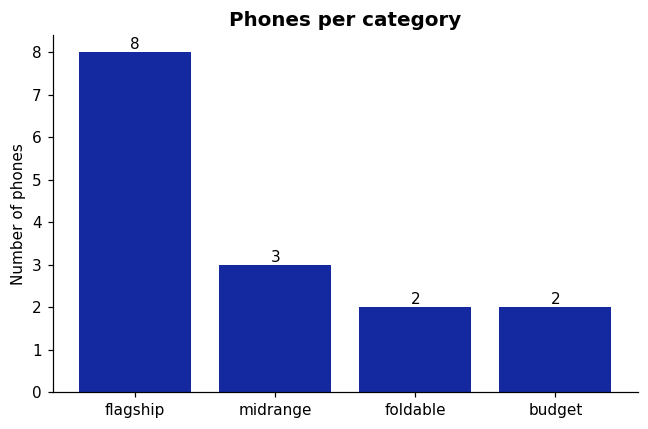

In [5]:
category_counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(category_counts.index, category_counts.values, color=SAMSUNG_BLUE)
ax.set_title("Phones per category", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of phones")
for bar in bars:
    h = bar.get_height()
    ax.annotate(str(h), (bar.get_x()+bar.get_width()/2, h), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Price distribution

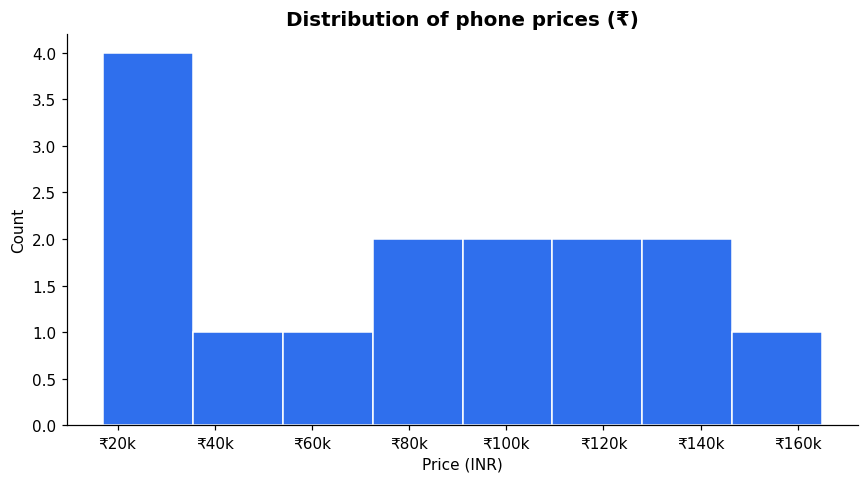

In [6]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(df["price_inr"], bins=8, color=ACCENT_BLUE, edgecolor="white")
ax.set_title("Distribution of phone prices (₹)", fontsize=13, fontweight="bold")
ax.set_xlabel("Price (INR)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x/1000)}k"))
plt.tight_layout()
plt.show()

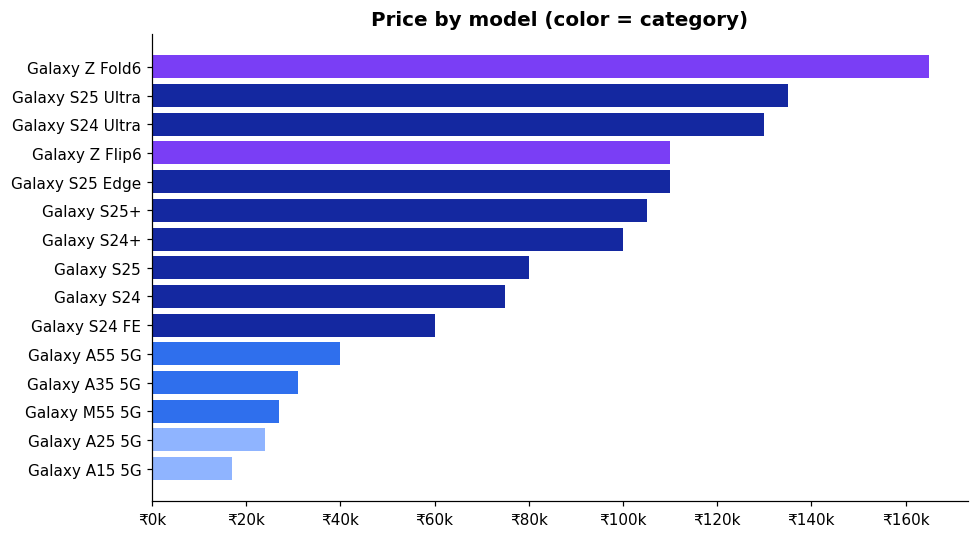

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
sorted_df = df.sort_values("price_inr")
colors = sorted_df["category"].map({
    "flagship": SAMSUNG_BLUE, "foldable": "#7A3EF5",
    "midrange": ACCENT_BLUE, "budget": "#8FB4FF"
})
ax.barh(sorted_df["model"], sorted_df["price_inr"], color=colors)
ax.set_title("Price by model (color = category)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x/1000)}k"))
plt.tight_layout()
plt.show()

**Insight:** Prices range from budget phones around ₹17–24k up to the
Z Fold6 at ₹1.65L. Flagship S-series and foldables dominate the top of the
range, while the A-series and M55 anchor the affordable end — a healthy
spread for persona-based recommendations across all budgets.

## 4. Spec vs. price relationships

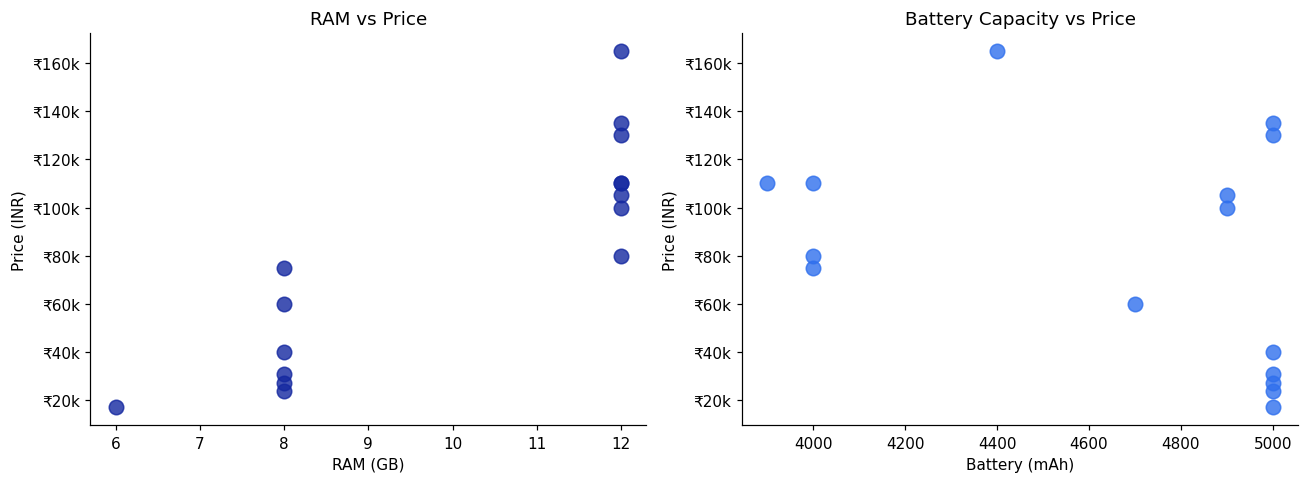

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].scatter(df["ram_gb"], df["price_inr"], s=90, color=SAMSUNG_BLUE, alpha=0.8)
axes[0].set_xlabel("RAM (GB)"); axes[0].set_ylabel("Price (INR)")
axes[0].set_title("RAM vs Price")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x/1000)}k"))

axes[1].scatter(df["battery_mah"], df["price_inr"], s=90, color=ACCENT_BLUE, alpha=0.8)
axes[1].set_xlabel("Battery (mAh)"); axes[1].set_ylabel("Price (INR)")
axes[1].set_title("Battery Capacity vs Price")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x/1000)}k"))

plt.tight_layout()
plt.show()

**Insight:** RAM shows a rough upward trend with price but plateaus at 12GB
across most mid-to-high phones. Battery capacity is *not* strongly tied to
price — budget phones pack the same 5000mAh cells as flagships, since
flagships instead trade cell size for slimmer designs (S25 Edge, S24/S25 base) offset by faster charging.

## 5. Camera hardware comparison

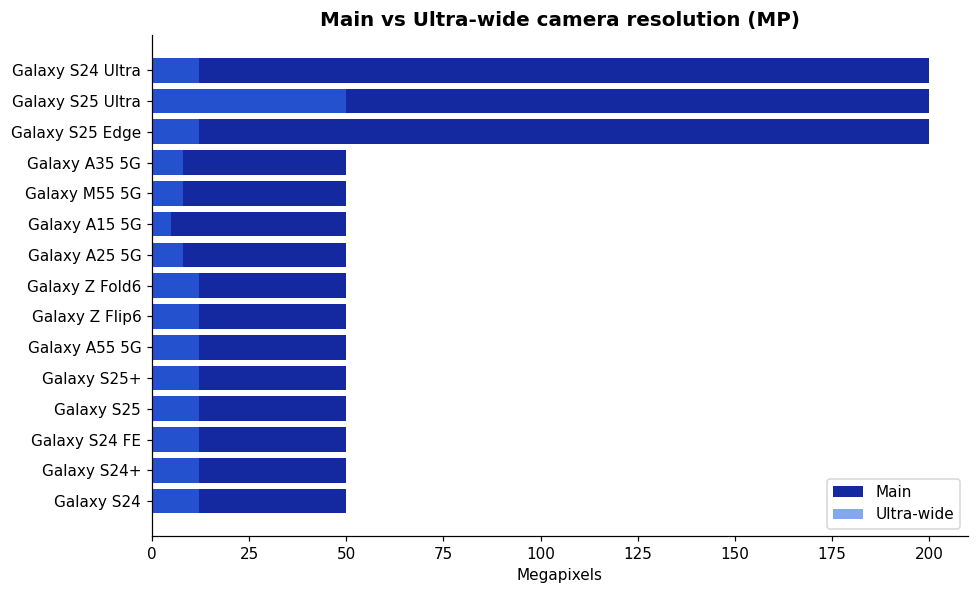

In [9]:
cam_df = df.sort_values("main_camera_mp", ascending=True)
fig, ax = plt.subplots(figsize=(9,5.5))
ax.barh(cam_df["model"], cam_df["main_camera_mp"], color=SAMSUNG_BLUE, label="Main")
ax.barh(cam_df["model"], cam_df["ultra_wide_mp"], color=ACCENT_BLUE, alpha=0.6, label="Ultra-wide")
ax.set_title("Main vs Ultra-wide camera resolution (MP)", fontsize=13, fontweight="bold")
ax.set_xlabel("Megapixels")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Correlation between numeric specs

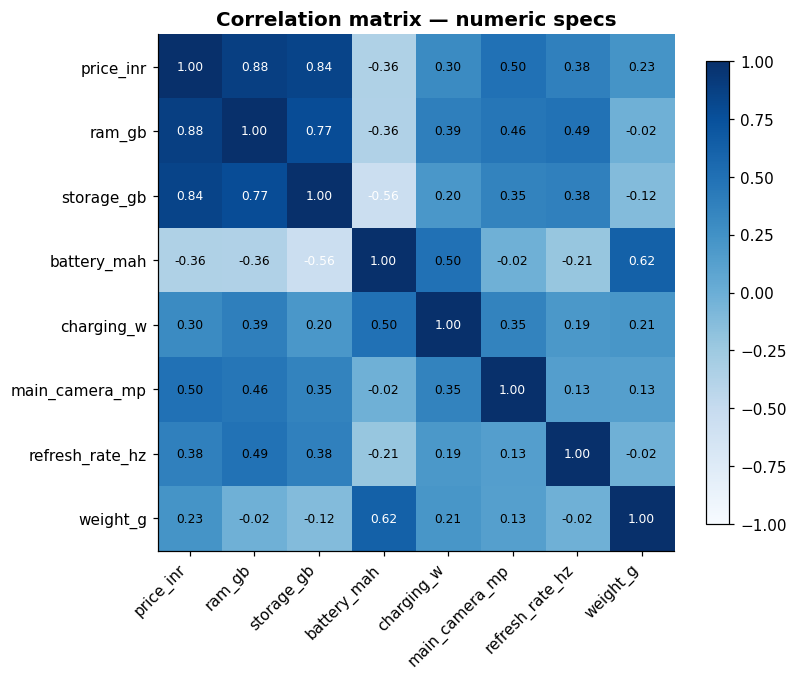

In [10]:
numeric_cols = ["price_inr", "ram_gb", "storage_gb", "battery_mah", "charging_w",
                "main_camera_mp", "refresh_rate_hz", "weight_g"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7.5,6.5))
im = ax.imshow(corr, cmap="Blues", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j])>0.5 else "black", fontsize=8)
ax.set_title("Correlation matrix — numeric specs", fontsize=13, fontweight="bold")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

**Insight:** Price correlates most strongly with `main_camera_mp` and
`charging_w` in this catalog, reflecting how Samsung uses camera hardware
(especially the 200MP sensor on Ultra models) as a key flagship
differentiator. Battery mAh and weight correlate positively — bigger cells
add heft, most visible on the Z Fold6.

## 7. Engineered scores (0–10) used by the recommender

In [11]:
score_cols = ["camera_score", "performance_score", "battery_score", "value_score"]
df[["model"] + score_cols].set_index("model").round(2)

,camera_score,performance_score,battery_score,value_score
model,,,,
Galaxy S24,1.26,8.34,0.70,1.06
Galaxy S24+,1.26,8.76,9.30,4.33
Galaxy S24 Ultra,8.65,9.25,10.00,6.60
Galaxy S24 FE,1.05,7.60,5.58,3.92
Galaxy S25,1.26,10.00,0.70,1.71
Galaxy S25+,1.26,10.00,9.30,4.66
Galaxy S25 Ultra,10.00,10.00,10.00,7.20
Galaxy S25 Edge,6.02,10.00,0.00,2.55
Galaxy Z Fold6,1.18,9.25,3.49,0.59


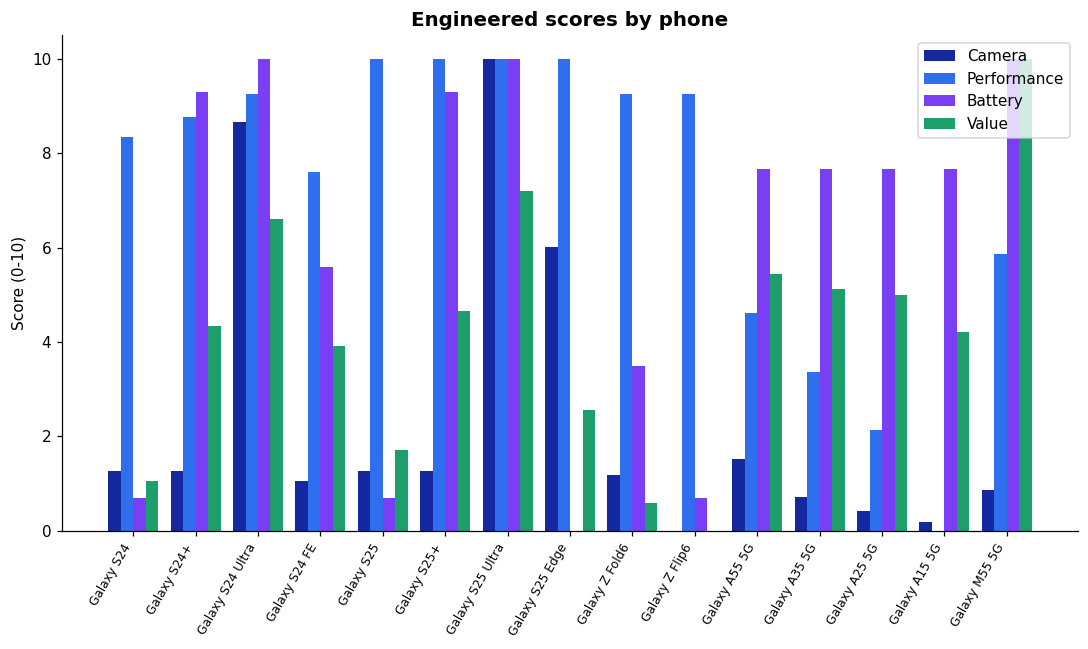

In [12]:
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(df))
width = 0.2
colors = [SAMSUNG_BLUE, ACCENT_BLUE, "#7A3EF5", "#1E9E6B"]
for i, col in enumerate(score_cols):
    ax.bar(x + i*width, df[col], width=width, label=col.replace("_score","").title(), color=colors[i])
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df["model"], rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Score (0-10)")
ax.set_title("Engineered scores by phone", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** The score engineering successfully differentiates the catalog —
Ultra models dominate Camera and Performance, the M-series and A-series
dominate Value, and Battery scores cluster budget/midrange phones together
(they all ship the same 5000mAh cell). This spread is what makes the
Weighted Sum Model produce meaningfully different Top-3 lists per persona.

## 8. Quick persona simulation (sanity check)

In [13]:
import sys
sys.path.append("..")
from personas import PERSONAS
from recommender import get_top_recommendations

for pid, persona in PERSONAS.items():
    print(f"\n=== {persona['name']} ===")
    top3 = get_top_recommendations(persona["weights"], persona["default_budget"], csv_path="../phones.csv")
    for _, row in top3.iterrows():
        print(f"  #{row['rank']} {row['model']:20s} match={row['match_score']}%  ₹{row['price_inr']:,}")


=== Camera Enthusiast / Content Creator ===
  #1 Galaxy S25 Ultra     match=95.8%  ₹134,999
  #2 Galaxy S24 Ultra     match=86.6%  ₹129,999
  #3 Galaxy S25 Edge      match=53.9%  ₹109,999

=== Gamer / Power User ===
  #1 Galaxy S25+          match=79.8%  ₹104,999
  #2 Galaxy S24+          match=73.3%  ₹99,999
  #3 Galaxy M55 5G        match=65.6%  ₹26,999

=== Student / Budget Buyer ===
  #1 Galaxy M55 5G        match=80.1%  ₹26,999
  #2 Galaxy A35 5G        match=48.4%  ₹30,999
  #3 Galaxy A25 5G        match=45.5%  ₹23,999

=== Business / All-Rounder ===
  #1 Galaxy S25 Ultra     match=94.4%  ₹134,999
  #2 Galaxy S24 Ultra     match=88.2%  ₹129,999
  #3 Galaxy S25+          match=69.7%  ₹104,999


## Summary

- The cleaned dataset (`phones.csv`) has **15 phones, 0 missing values, no
  duplicates or unrealistic prices** after the `data_cleaning.py` pipeline.
- Price is most influenced by camera hardware and charging speed; battery
  capacity is fairly constant across the catalog.
- The 4 engineered scores (Camera / Performance / Battery / Value) show
  healthy spread and clearly favor different phones — exactly what's needed
  for the Weighted Sum Model to produce persona-specific rankings.
- A quick simulation across all 4 personas confirms distinct, sensible
  Top-3 recommendations for each buyer profile.
